# 01 — Exploratory Data Analysis

This notebook explores the NSL-KDD dataset to understand its structure, class distributions, and feature characteristics.

In [1]:
import sys
sys.path.append('../')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocess import COLUMNS, ATTACK_MAP

sns.set_theme(style='whitegrid')
%matplotlib inline

## Load Data

In [2]:
train = pd.read_csv('../NSLKDD/KDDTrain+.txt', header=None, names=COLUMNS)
test  = pd.read_csv('../NSLKDD/KDDTest+.txt',  header=None, names=COLUMNS)

print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')
train.head()

Train shape: (125973, 43)
Test shape:  (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


## Basic Info

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [4]:
train.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [5]:
# Check for missing values
print('Missing values per column:')
print(train.isnull().sum().sum(), 'total missing')

Missing values per column:
0 total missing


## Class Distribution

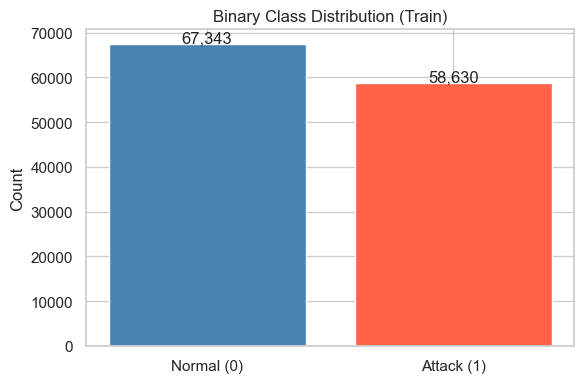

binary_label
0    67343
1    58630
Name: count, dtype: int64


In [6]:
# Binary: normal vs attack
train['binary_label'] = (train['label'] != 'normal').astype(int)
counts = train['binary_label'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Normal (0)', 'Attack (1)'], counts.values, color=['steelblue', 'tomato'])
ax.set_title('Binary Class Distribution (Train)')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 500, f'{v:,}', ha='center')
plt.tight_layout()
plt.show()
print(counts)

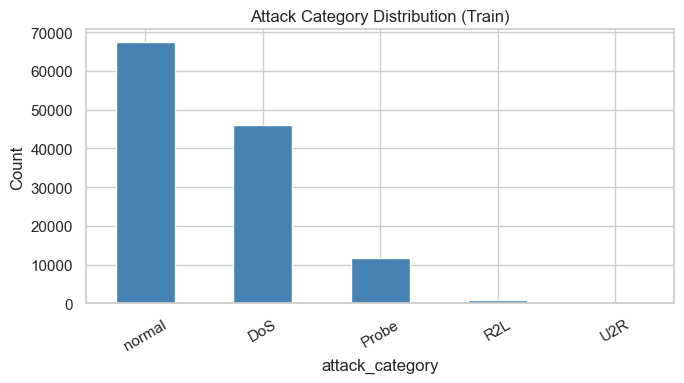

attack_category
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


In [7]:
# Multi-class attack categories
train['attack_category'] = train['label'].map(ATTACK_MAP).fillna('other')
cat_counts = train['attack_category'].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
cat_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Attack Category Distribution (Train)')
ax.set_ylabel('Count')
ax.set_xticklabels(cat_counts.index, rotation=30)
plt.tight_layout()
plt.show()
print(cat_counts)

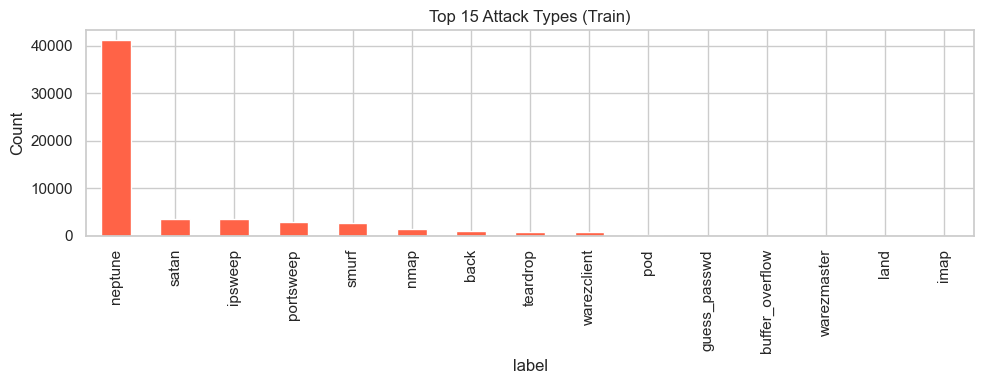

In [8]:
# Top 15 individual attack labels
top_attacks = train[train['label'] != 'normal']['label'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 4))
top_attacks.plot(kind='bar', ax=ax, color='tomato')
ax.set_title('Top 15 Attack Types (Train)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## Feature Analysis

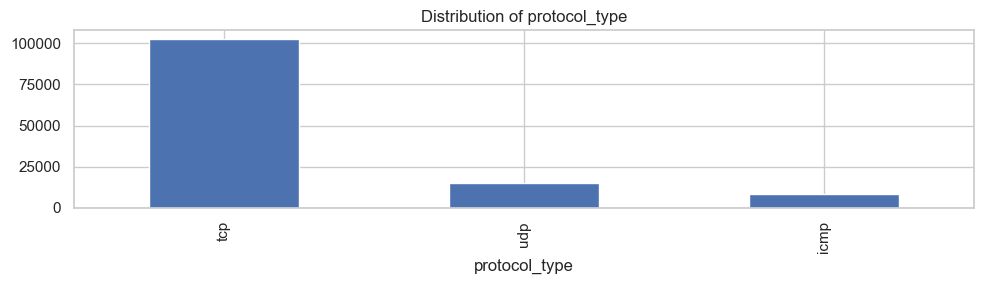

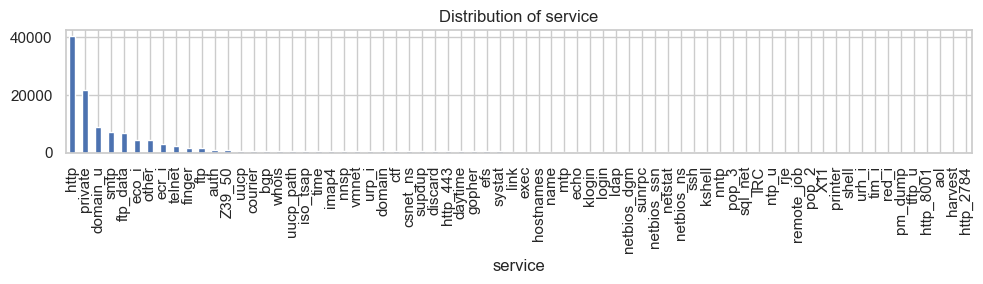

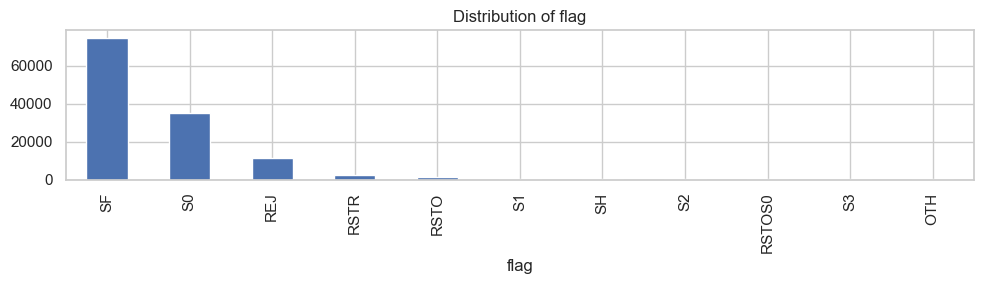

In [9]:
# Categorical feature distributions
for col in ['protocol_type', 'service', 'flag']:
    fig, ax = plt.subplots(figsize=(10, 3))
    train[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

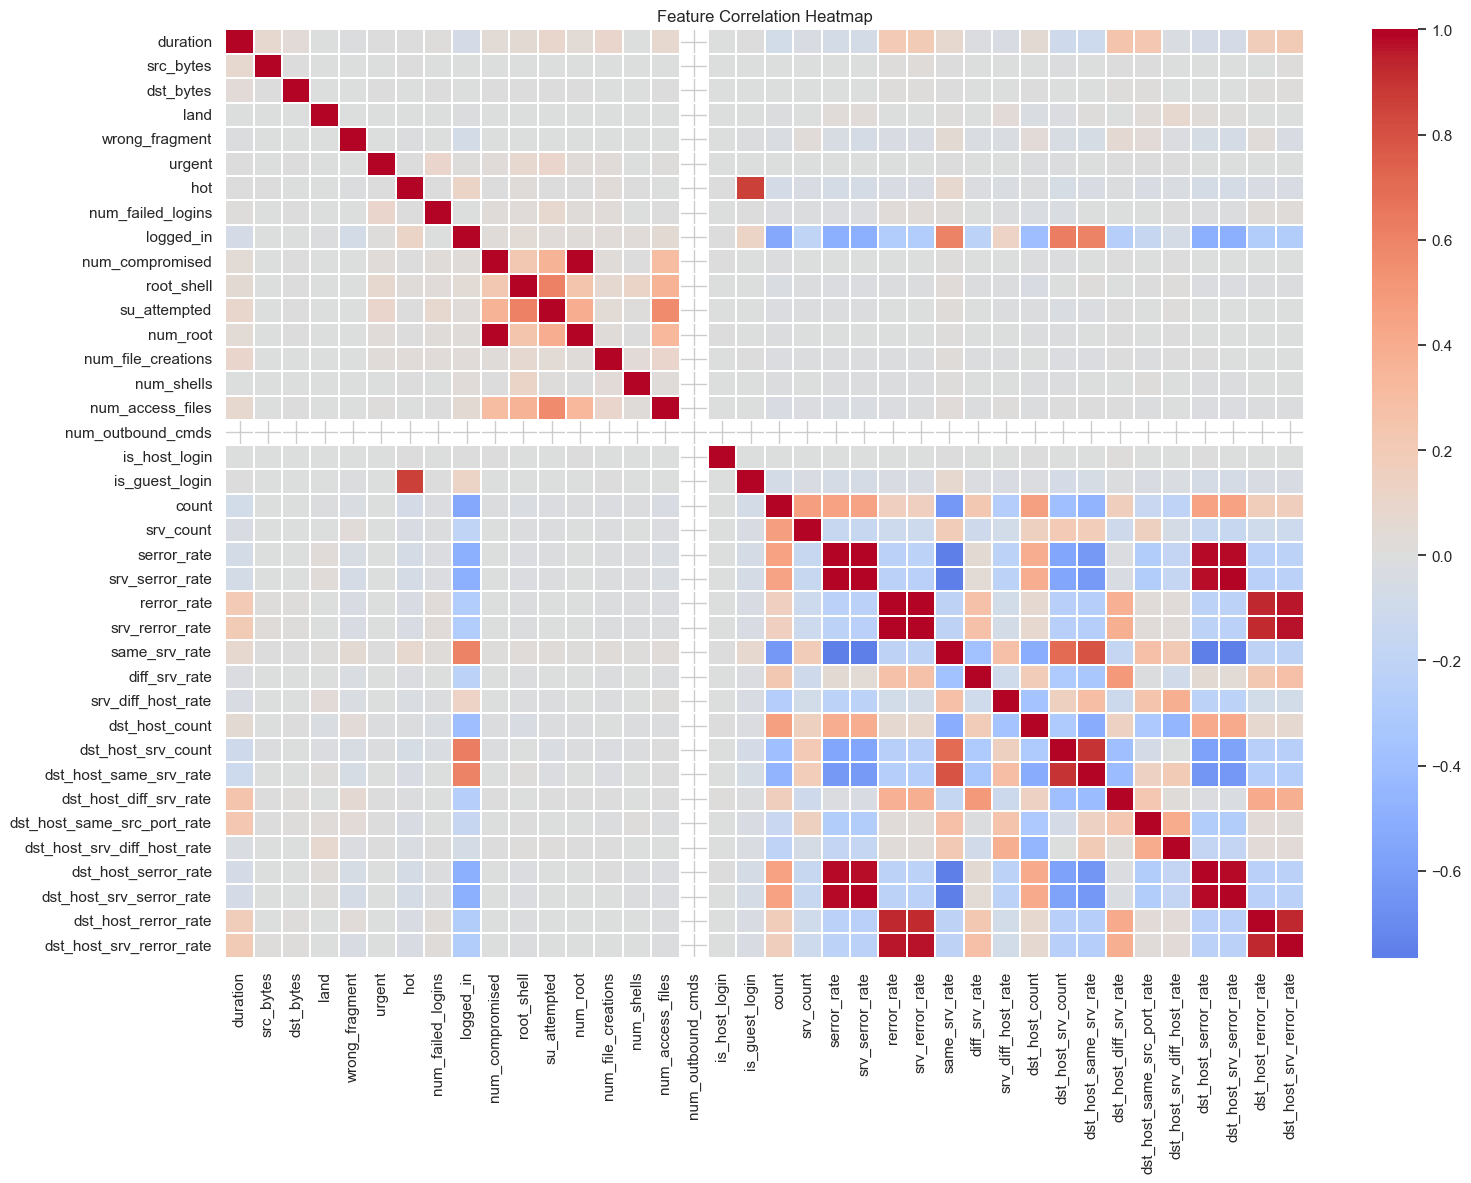

In [10]:
# Correlation heatmap (numeric features)
numeric_cols = train.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ('binary_label', 'difficulty')]

corr = train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax, linewidths=0.3)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

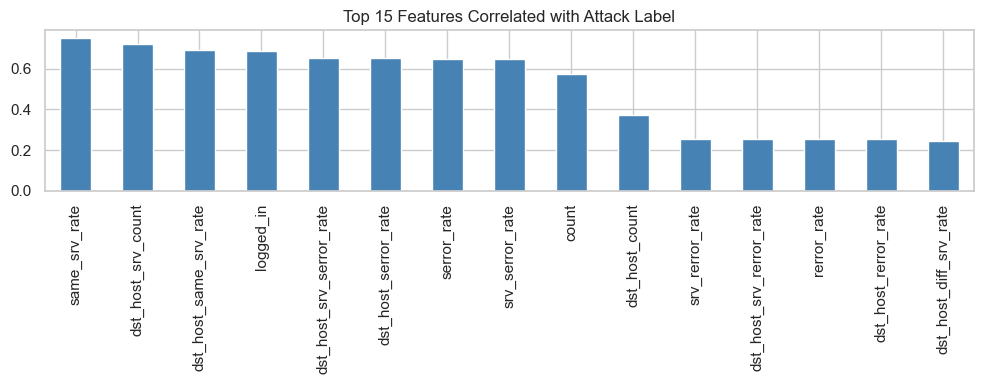

In [11]:
# Features most correlated with binary label
corr_with_label = train[numeric_cols + ['binary_label']].corr()['binary_label'].drop('binary_label')
corr_with_label.abs().sort_values(ascending=False).head(15).plot(
    kind='bar', figsize=(10, 4), color='steelblue',
    title='Top 15 Features Correlated with Attack Label'
)
plt.tight_layout()
plt.show()